# Multi-Subject MVPA Decoding (Single-Trial GLM Betas)
**Analyses:** Within-source & cross-source decoding using single trial betas (3 z-score variants), averaged betas (random grouping inside CV), and ERP stimulus-averaged betas.

**Z-scoring variants:**
- **No z**: raw betas
- **Trial z**: pattern norm (axis=1) + mean-center (axis=0), applied inside CV folds
- **Source z**: pattern norm + mean-center within each source (Natural/AI separately), applied before CV

In [7]:
import os, re, gc
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn.image import resample_img
from sklearn.svm import SVC
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, KFold
from scipy.stats import zscore
from tqdm.notebook import tqdm
import warnings, pickle, scipy.io
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

## Configuration

In [8]:
beta_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\GLM_singletrial\betas'
label_file = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\GLM_singletrial\beta_groups.csv'
mask_file = r'N:\Experimental_Data\yujunchen\projects\data\masks\MNI152_T1_2mm_brain_mask.nii.gz'
roi_pkl = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\kastner_dict.pkl'
onset_base_dir = r'N:\Experimental_Data\yujunchen\projects\LAB_IAPS_AI\DataRecording'

subs = ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9',
        'Sub11', 'Sub12', 'Sub13', 'Sub14', 'Sub15', 'Sub16', 'Sub17', 'Sub18',
        'Sub19', 'Sub20', 'Sub21', 'Sub22', 'Sub23', 'Sub24', 'Sub25', 'Sub26',
        'Sub27', 'Sub28', 'Sub29', 'Sub30', 'Sub31']

onset_dir = r'N:\Experimental_Data\yujunchen\projects\LAB_IAPS_AI\DataRecording\Sub27\LogFiles'
runs = ['Run01','Run02','Run03','Run04','Run05','Run06','Run07','Run08','Run09','Run10']

N_REPEATS = 50
N_FOLDS = 4
N_JOBS = 6  # parallel subjects (adjust based on RAM: ~1.5 GB per job)

natural_cats = ['pleasant', 'neutral', 'unpleasant']
ai_cats = ['pleasantAI', 'neutralAI', 'unpleasantAI']
all_categories = natural_cats + ai_cats

within_comparisons = [
    ('pleasantAI', 'neutralAI'),
    ('pleasant', 'neutral'),
    ('unpleasantAI', 'neutralAI'),
    ('unpleasant', 'neutral'),
]

cross_comparisons = [
    ('pleasantAI', 'neutralAI', 'pleasant', 'neutral'),
    ('pleasant', 'neutral', 'pleasantAI', 'neutralAI'),
    ('unpleasantAI', 'neutralAI', 'unpleasant', 'neutral'),
    ('unpleasant', 'neutral', 'unpleasantAI', 'neutralAI'),
]

## Build Stimulus → Category Lookup
Use Sub27's onset files + beta_groups.csv to map each stimulus filename to its category.

In [9]:
_bl = pd.read_csv(label_file, header=None, names=['beta_file', 'category'])
beta_file_list = _bl['beta_file'].tolist()

_stim = []
for run_name in runs:
    _mat = scipy.io.loadmat(os.path.join(onset_base_dir, 'Sub27', 'LogFiles', f'{run_name}.mat'), squeeze_me=False)
    _raw = _mat['dataLog']
    for _row in range(1, _raw.shape[0]):
        _c = _raw[_row, 1]
        if _c.size == 0: continue
        if str(_c.flat[0]).strip() == 'Stim on':
            _stim.append(str(_raw[_row, 2].flat[0]).strip())

stim_to_category = dict(zip(_stim, _bl['category']))
print(f"Lookup built: {len(stim_to_category)} stimuli -> 6 categories")
for cat in sorted(set(stim_to_category.values())):
    print(f"  {cat}: {sum(1 for v in stim_to_category.values() if v == cat)}")
del _bl, _stim, _mat, _raw

Lookup built: 120 stimuli -> 6 categories
  neutral: 20
  neutralAI: 20
  pleasant: 20
  pleasantAI: 20
  unpleasant: 20
  unpleasantAI: 20


## Helper Functions

In [10]:
def get_roi_voxels(roi_mask, ref_img):
    resampled = resample_img(roi_mask, target_affine=ref_img.affine,
                              target_shape=ref_img.shape)
    return np.where(resampled.get_fdata().flatten() > 0)[0]

def extract_roi_data(data, labels, conditions, voxel_idx):
    cond_data = {}
    for cond in conditions:
        idx = labels[labels['category'] == cond].index.values
        cond_data[cond] = data[idx][:, voxel_idx]
    valid = np.ones(len(voxel_idx), dtype=bool)
    for cond in conditions:
        valid &= ~np.any(np.isnan(cond_data[cond]), axis=0)
    for cond in conditions:
        cond_data[cond] = cond_data[cond][:, valid]
    return cond_data, np.sum(valid)

def compute_source_zscore(cond_data_dict):
    """Source-level z-scoring: normalize all conditions within each source together.
    (1) pattern norm per trial (axis=1), (2) standardize across trials within source (axis=0)."""
    result = {}
    for source_cats in [natural_cats, ai_cats]:
        present = [c for c in source_cats if c in cond_data_dict]
        if not present: continue
        all_data = np.vstack([cond_data_dict[c] for c in present])
        sizes = [len(cond_data_dict[c]) for c in present]
        all_z = zscore(all_data, axis=1)
        all_z = np.nan_to_num(all_z, nan=0.0)
        m = np.mean(all_z, axis=0)
        s = np.std(all_z, axis=0); s[s == 0] = 1
        all_z = (all_z - m) / s
        idx = 0
        for c, sz in zip(present, sizes):
            result[c] = all_z[idx:idx+sz]
            idx += sz
    return result

def decode_within_source(d1, d2, use_zscore=False, n_repeats=N_REPEATS, n_folds=N_FOLDS):
    X = np.vstack([d1, d2])
    y = np.array([1]*len(d1) + [0]*len(d2))
    accuracies = []
    rskf = RepeatedStratifiedKFold(n_splits=n_folds, n_repeats=n_repeats, random_state=42)
    for train_idx, test_idx in rskf.split(X, y):
        X_train, X_test = X[train_idx].copy(), X[test_idx].copy()
        if use_zscore:
            X_train = zscore(X_train, axis=1); X_train = np.nan_to_num(X_train, nan=0.0)
            X_test = zscore(X_test, axis=1); X_test = np.nan_to_num(X_test, nan=0.0)
            train_mean = np.mean(X_train, axis=0)
            train_std = np.std(X_train, axis=0); train_std[train_std == 0] = 1
            X_train = (X_train - train_mean) / train_std
            X_test = (X_test - train_mean) / train_std
        clf = SVC(kernel='linear', C=1.0)
        clf.fit(X_train, y[train_idx])
        accuracies.append(clf.score(X_test, y[test_idx]))
    return np.mean(accuracies)

def decode_within_avg(d1, d2, n_repeats=20, n_folds=4, n_avg_groups=3):
    accuracies = []
    for repeat in range(n_repeats):
        kf = KFold(n_splits=n_folds, shuffle=True, random_state=42 + repeat)
        indices = np.arange(d1.shape[0])
        for train_idx, test_idx in kf.split(indices):
            train_d1_avg = np.array([np.mean(ch, axis=0) for ch in np.array_split(d1[train_idx], n_avg_groups)])
            train_d2_avg = np.array([np.mean(ch, axis=0) for ch in np.array_split(d2[train_idx], n_avg_groups)])
            test_d1_avg = np.mean(d1[test_idx], axis=0, keepdims=True)
            test_d2_avg = np.mean(d2[test_idx], axis=0, keepdims=True)
            X_train = np.vstack([train_d1_avg, train_d2_avg])
            y_train = np.array([1]*len(train_d1_avg) + [0]*len(train_d2_avg))
            X_test = np.vstack([test_d1_avg, test_d2_avg])
            y_test = np.array([1, 0])
            clf = SVC(kernel='linear', C=1.0)
            clf.fit(X_train, y_train)
            accuracies.append(clf.score(X_test, y_test))
    return np.mean(accuracies)

def decode_cross_source(train_d1, train_d2, test_d1, test_d2):
    X_train = np.vstack([train_d1, train_d2])
    y_train = np.array([1]*len(train_d1) + [0]*len(train_d2))
    X_test = np.vstack([test_d1, test_d2])
    y_test = np.array([1]*len(test_d1) + [0]*len(test_d2))
    clf = SVC(kernel='linear', C=1.0)
    clf.fit(X_train, y_train)
    return clf.score(X_test, y_test)

def decode_cross_avg(train_d1, train_d2, test_d1, test_d2, n_repeats=20, n_folds=4):
    accuracies = []
    for repeat in range(n_repeats):
        perm = np.random.RandomState(42 + repeat).permutation(train_d1.shape[0])
        groups = np.array_split(perm, n_folds)
        td1a = np.array([np.mean(train_d1[g], axis=0) for g in groups])
        td2a = np.array([np.mean(train_d2[g], axis=0) for g in groups])
        te1a = np.array([np.mean(test_d1[g], axis=0) for g in groups])
        te2a = np.array([np.mean(test_d2[g], axis=0) for g in groups])
        X_train = np.vstack([td1a, td2a])
        y_train = np.array([1]*len(td1a) + [0]*len(td2a))
        X_test = np.vstack([te1a, te2a])
        y_test = np.array([1]*len(te1a) + [0]*len(te2a))
        clf = SVC(kernel='linear', C=1.0)
        clf.fit(X_train, y_train)
        accuracies.append(clf.score(X_test, y_test))
    return np.mean(accuracies)

def average_by_stimulus(data, labels, condition):
    mask = labels['category'] == condition
    idx = labels[mask].index.values
    stim_names = labels.loc[idx, 'stimulus'].values
    cond_data = data[idx]
    unique_stims = np.unique(stim_names)
    averaged = np.array([np.mean(cond_data[stim_names == s], axis=0) for s in unique_stims])
    return averaged, unique_stims

def extract_roi_erp(data, labels, conditions, voxel_idx):
    cond_data = {}
    cond_stims = {}
    for cond in conditions:
        avg_data, stim_names = average_by_stimulus(data, labels, cond)
        cond_data[cond] = avg_data[:, voxel_idx]
        cond_stims[cond] = stim_names
    valid = np.ones(len(voxel_idx), dtype=bool)
    for cond in conditions:
        valid &= ~np.any(np.isnan(cond_data[cond]), axis=0)
    for cond in conditions:
        cond_data[cond] = cond_data[cond][:, valid]
    return cond_data, np.sum(valid), cond_stims

def decode_within_erp(d1, d2, n_repeats=10, n_folds=5):
    X = np.vstack([d1, d2])
    y = np.array([1]*len(d1) + [0]*len(d2))
    accuracies = []
    for repeat in range(n_repeats):
        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42 + repeat)
        for train_idx, test_idx in skf.split(X, y):
            clf = SVC(kernel='linear', C=1.0)
            clf.fit(X[train_idx], y[train_idx])
            accuracies.append(clf.score(X[test_idx], y[test_idx]))
    return np.mean(accuracies)

def decode_cross_erp(train_d1, train_d2, test_d1, test_d2):
    X_train = np.vstack([train_d1, train_d2])
    y_train = np.array([1]*len(train_d1) + [0]*len(train_d2))
    X_test = np.vstack([test_d1, test_d2])
    y_test = np.array([1]*len(test_d1) + [0]*len(test_d2))
    clf = SVC(kernel='linear', C=1.0)
    clf.fit(X_train, y_train)
    return clf.score(X_test, y_test)

## Load ROI Masks

In [11]:
with open(roi_pkl, 'rb') as f:
    roi_masks = pickle.load(f)
mask_img = nib.load(mask_file)
print(f"Loaded {len(roi_masks)} ROIs")

Loaded 16 ROIs


## Main Analysis Loop
Process each subject: load onsets, load betas, run all decoding analyses.

In [12]:
def process_one_subject(sub):
    """Process all decoding analyses for a single subject."""

    # Init result containers
    ws = {f"{c1}_vs_{c2}": {'no_zscore': {}, 'trial_zscore': {}, 'source_zscore': {}}
          for c1, c2 in within_comparisons}
    wa = {f"{c1}_vs_{c2}": {} for c1, c2 in within_comparisons}
    we = {f"{c1}_vs_{c2}": {} for c1, c2 in within_comparisons}
    cs = {f"train_{c1}v{c2}_test_{c3}v{c4}": {'no_zscore': {}, 'trial_zscore': {}, 'source_zscore': {}}
          for c1, c2, c3, c4 in cross_comparisons}
    ca = {f"train_{c1}v{c2}_test_{c3}v{c4}": {} for c1, c2, c3, c4 in cross_comparisons}
    ce = {f"train_{c1}v{c2}_test_{c3}v{c4}": {} for c1, c2, c3, c4 in cross_comparisons}

    # --- Load onsets ---
    sub_onset_dir = os.path.join(onset_base_dir, sub, 'LogFiles')
    stim_names = []
    for run_name in runs:
        fpath = os.path.join(sub_onset_dir, f'{run_name}.mat')
        if not os.path.exists(fpath):
            alt_name = 'Run' + str(int(run_name.replace('Run', '')))
            fpath = os.path.join(sub_onset_dir, f'{alt_name}.mat')
        mat = scipy.io.loadmat(fpath, squeeze_me=False)
        raw = mat['dataLog']
        for row in range(1, raw.shape[0]):
            c = raw[row, 1]
            if c.size == 0: continue
            if str(c.flat[0]).strip() == 'Stim on':
                stim_names.append(str(raw[row, 2].flat[0]).strip())

    categories = [stim_to_category[s] for s in stim_names]
    bl = pd.DataFrame({'beta_file': beta_file_list, 'category': categories, 'stimulus': stim_names})

    # --- Load betas ---
    sub_dir = os.path.join(beta_dir, sub)
    first_img = nib.load(os.path.join(sub_dir, bl['beta_file'].iloc[0]))
    ref_img_global = first_img
    n_vox = int(np.prod(first_img.shape))
    data = np.zeros((600, n_vox), dtype=np.float32)
    for idx in range(600):
        data[idx] = nib.load(os.path.join(sub_dir, bl.iloc[idx]['beta_file'])).get_fdata().flatten().astype(np.float32)

    # --- Process each ROI ---
    for roi_name, roi_mask in roi_masks.items():
        voxel_idx = get_roi_voxels(roi_mask, ref_img_global)

        # Extract all conditions
        cond_data = {}
        for cond in all_categories:
            idx_arr = bl[bl['category'] == cond].index.values
            cond_data[cond] = data[idx_arr][:, voxel_idx]
        # Remove NaN voxels
        valid = np.ones(len(voxel_idx), dtype=bool)
        for cond in all_categories:
            valid &= ~np.any(np.isnan(cond_data[cond]), axis=0)
        n_valid = np.sum(valid)
        if n_valid < 10:
            continue
        for cond in all_categories:
            cond_data[cond] = cond_data[cond][:, valid]

        source_z = compute_source_zscore(cond_data)

        # ERP data (average by stimulus identity)
        erp_data = {}
        for cond in all_categories:
            mask = bl['category'] == cond
            idx_arr = bl[mask].index.values
            stim_arr = bl.loc[idx_arr, 'stimulus'].values
            cond_raw = data[idx_arr][:, voxel_idx][:, valid]
            unique_stims = np.unique(stim_arr)
            erp_data[cond] = np.array([np.mean(cond_raw[stim_arr == s], axis=0) for s in unique_stims])
        erp_valid = all(not np.any(np.isnan(erp_data[c])) for c in all_categories)

        # --- Within-source ---
        for cond1, cond2 in within_comparisons:
            comp = f"{cond1}_vs_{cond2}"
            d1, d2 = cond_data[cond1], cond_data[cond2]

            ws[comp]['no_zscore'][roi_name] = decode_within_source(d1, d2, use_zscore=False)
            ws[comp]['trial_zscore'][roi_name] = decode_within_source(d1, d2, use_zscore=True)
            ws[comp]['source_zscore'][roi_name] = decode_within_source(
                source_z[cond1], source_z[cond2], use_zscore=False)
            wa[comp][roi_name] = decode_within_avg(d1, d2, n_repeats=20, n_folds=4, n_avg_groups=3)
            if erp_valid:
                we[comp][roi_name] = decode_within_erp(erp_data[cond1], erp_data[cond2],
                                                       n_repeats=10, n_folds=5)

        # --- Cross-source ---
        for train_c1, train_c2, test_c1, test_c2 in cross_comparisons:
            comp = f"train_{train_c1}v{train_c2}_test_{test_c1}v{test_c2}"
            td1, td2 = cond_data[train_c1], cond_data[train_c2]
            ted1, ted2 = cond_data[test_c1], cond_data[test_c2]

            # No z
            cs[comp]['no_zscore'][roi_name] = decode_cross_source(td1, td2, ted1, ted2)

            # Trial z
            train_all = np.vstack([td1, td2])
            train_z = zscore(zscore(train_all, axis=1), axis=0)
            train_z = np.nan_to_num(train_z, nan=0.0)
            test_all = np.vstack([ted1, ted2])
            test_z = zscore(zscore(test_all, axis=1), axis=0)
            test_z = np.nan_to_num(test_z, nan=0.0)
            n1, n2 = len(td1), len(ted1)
            cs[comp]['trial_zscore'][roi_name] = decode_cross_source(
                train_z[:n1], train_z[n1:], test_z[:n2], test_z[n2:])

            # Source z
            cs[comp]['source_zscore'][roi_name] = decode_cross_source(
                source_z[train_c1], source_z[train_c2],
                source_z[test_c1], source_z[test_c2])

            ca[comp][roi_name] = decode_cross_avg(td1, td2, ted1, ted2, n_repeats=20, n_folds=4)
            if erp_valid:
                ce[comp][roi_name] = decode_cross_erp(
                    erp_data[train_c1], erp_data[train_c2],
                    erp_data[test_c1], erp_data[test_c2])

    return {'sub': sub, 'within_single': ws, 'within_avg': wa, 'within_erp': we,
            'cross_single': cs, 'cross_avg': ca, 'cross_erp': ce}


# --- Run in parallel ---
print(f"Processing {len(subs)} subjects with {N_JOBS} parallel jobs...")
print(f"Estimated RAM per job: ~1.5 GB. Total peak: ~{N_JOBS * 1.5:.0f} GB")

results_list = Parallel(n_jobs=N_JOBS, prefer='threads', verbose=10)(
    delayed(process_one_subject)(sub) for sub in subs
)

# --- Merge results ---
results_within_single = {}
results_within_avg = {}
results_within_erp = {}
results_cross_single = {}
results_cross_avg = {}
results_cross_erp = {}

for r in results_list:
    sub = r['sub']
    results_within_single[sub] = r['within_single']
    results_within_avg[sub] = r['within_avg']
    results_within_erp[sub] = r['within_erp']
    results_cross_single[sub] = r['cross_single']
    results_cross_avg[sub] = r['cross_avg']
    results_cross_erp[sub] = r['cross_erp']

print(f"\nAll {len(subs)} subjects complete.")

Processing 30 subjects with 6 parallel jobs...
Estimated RAM per job: ~1.5 GB. Total peak: ~9 GB


[Parallel(n_jobs=6)]: Using backend ThreadingBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed: 18.4min
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed: 26.9min
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed: 48.2min
[Parallel(n_jobs=6)]: Done  23 out of  30 | elapsed: 94.6min remaining: 28.8min
[Parallel(n_jobs=6)]: Done  27 out of  30 | elapsed: 116.4min remaining: 12.9min



All 30 subjects complete.


[Parallel(n_jobs=6)]: Done  30 out of  30 | elapsed: 160.0min finished


## Summary

In [13]:
roi_names = list(roi_masks.keys())

def print_group_summary(results_dict, title, has_zscore=False):
    print(f"\n{'='*70}")
    print(f"  {title}  (n={len(subs)} subjects, mean \u00b1 std)")
    print(f"{'='*70}")
    for comp in results_dict[subs[0]].keys():
        print(f"\n  {comp}:")
        if has_zscore:
            z_keys = ['no_zscore', 'trial_zscore', 'source_zscore']
            header = f"  {'ROI':<12}" + "".join(f"{'  '+k:>16}" for k in z_keys)
            print(header)
            print(f"  {'-'*60}")
            for roi in roi_names:
                vals = []
                for zk in z_keys:
                    v = [results_dict[s][comp][zk].get(roi, np.nan) for s in subs]
                    vals.append((np.nanmean(v), np.nanstd(v)))
                line = f"  {roi:<12}" + "".join(f"  {m:.3f}\u00b1{s:.3f}" for m, s in vals)
                print(line)
        else:
            print(f"  {'ROI':<12}  {'mean':>8}  {'std':>8}")
            print(f"  {'-'*32}")
            for roi in roi_names:
                v = [results_dict[s][comp].get(roi, np.nan) for s in subs]
                print(f"  {roi:<12}  {np.nanmean(v):>8.3f}  {np.nanstd(v):>8.3f}")

print_group_summary(results_within_single, 'Within-Source (Single Trial)', has_zscore=True)
print_group_summary(results_within_avg, 'Within-Source (Averaged)')
print_group_summary(results_within_erp, 'Within-Source (ERP Stimulus-Averaged)')
print_group_summary(results_cross_single, 'Cross-Source (Single Trial)', has_zscore=True)
print_group_summary(results_cross_avg, 'Cross-Source (Averaged)')
print_group_summary(results_cross_erp, 'Cross-Source (ERP Stimulus-Averaged)')


  Within-Source (Single Trial)  (n=30 subjects, mean ± std)

  pleasantAI_vs_neutralAI:
  ROI                no_zscore    trial_zscore   source_zscore
  ------------------------------------------------------------
  V1v           0.494±0.032  0.494±0.031  0.494±0.031
  V1d           0.491±0.029  0.491±0.029  0.492±0.029
  V2v           0.494±0.030  0.492±0.030  0.492±0.030
  V2d           0.485±0.029  0.483±0.026  0.483±0.025
  V3v           0.501±0.034  0.497±0.037  0.497±0.037
  V3d           0.502±0.029  0.500±0.032  0.500±0.032
  hV4           0.515±0.034  0.504±0.037  0.504±0.037
  V3a           0.497±0.033  0.496±0.032  0.496±0.032
  V3b           0.494±0.033  0.491±0.029  0.491±0.029
  LO1           0.507±0.031  0.501±0.030  0.500±0.030
  LO2           0.503±0.041  0.502±0.038  0.502±0.038
  VO1           0.506±0.029  0.504±0.029  0.504±0.029
  VO2           0.490±0.031  0.484±0.029  0.484±0.029
  IPS           0.502±0.029  0.501±0.030  0.501±0.030
  PHC1          0.483±0.033  

## Visualization

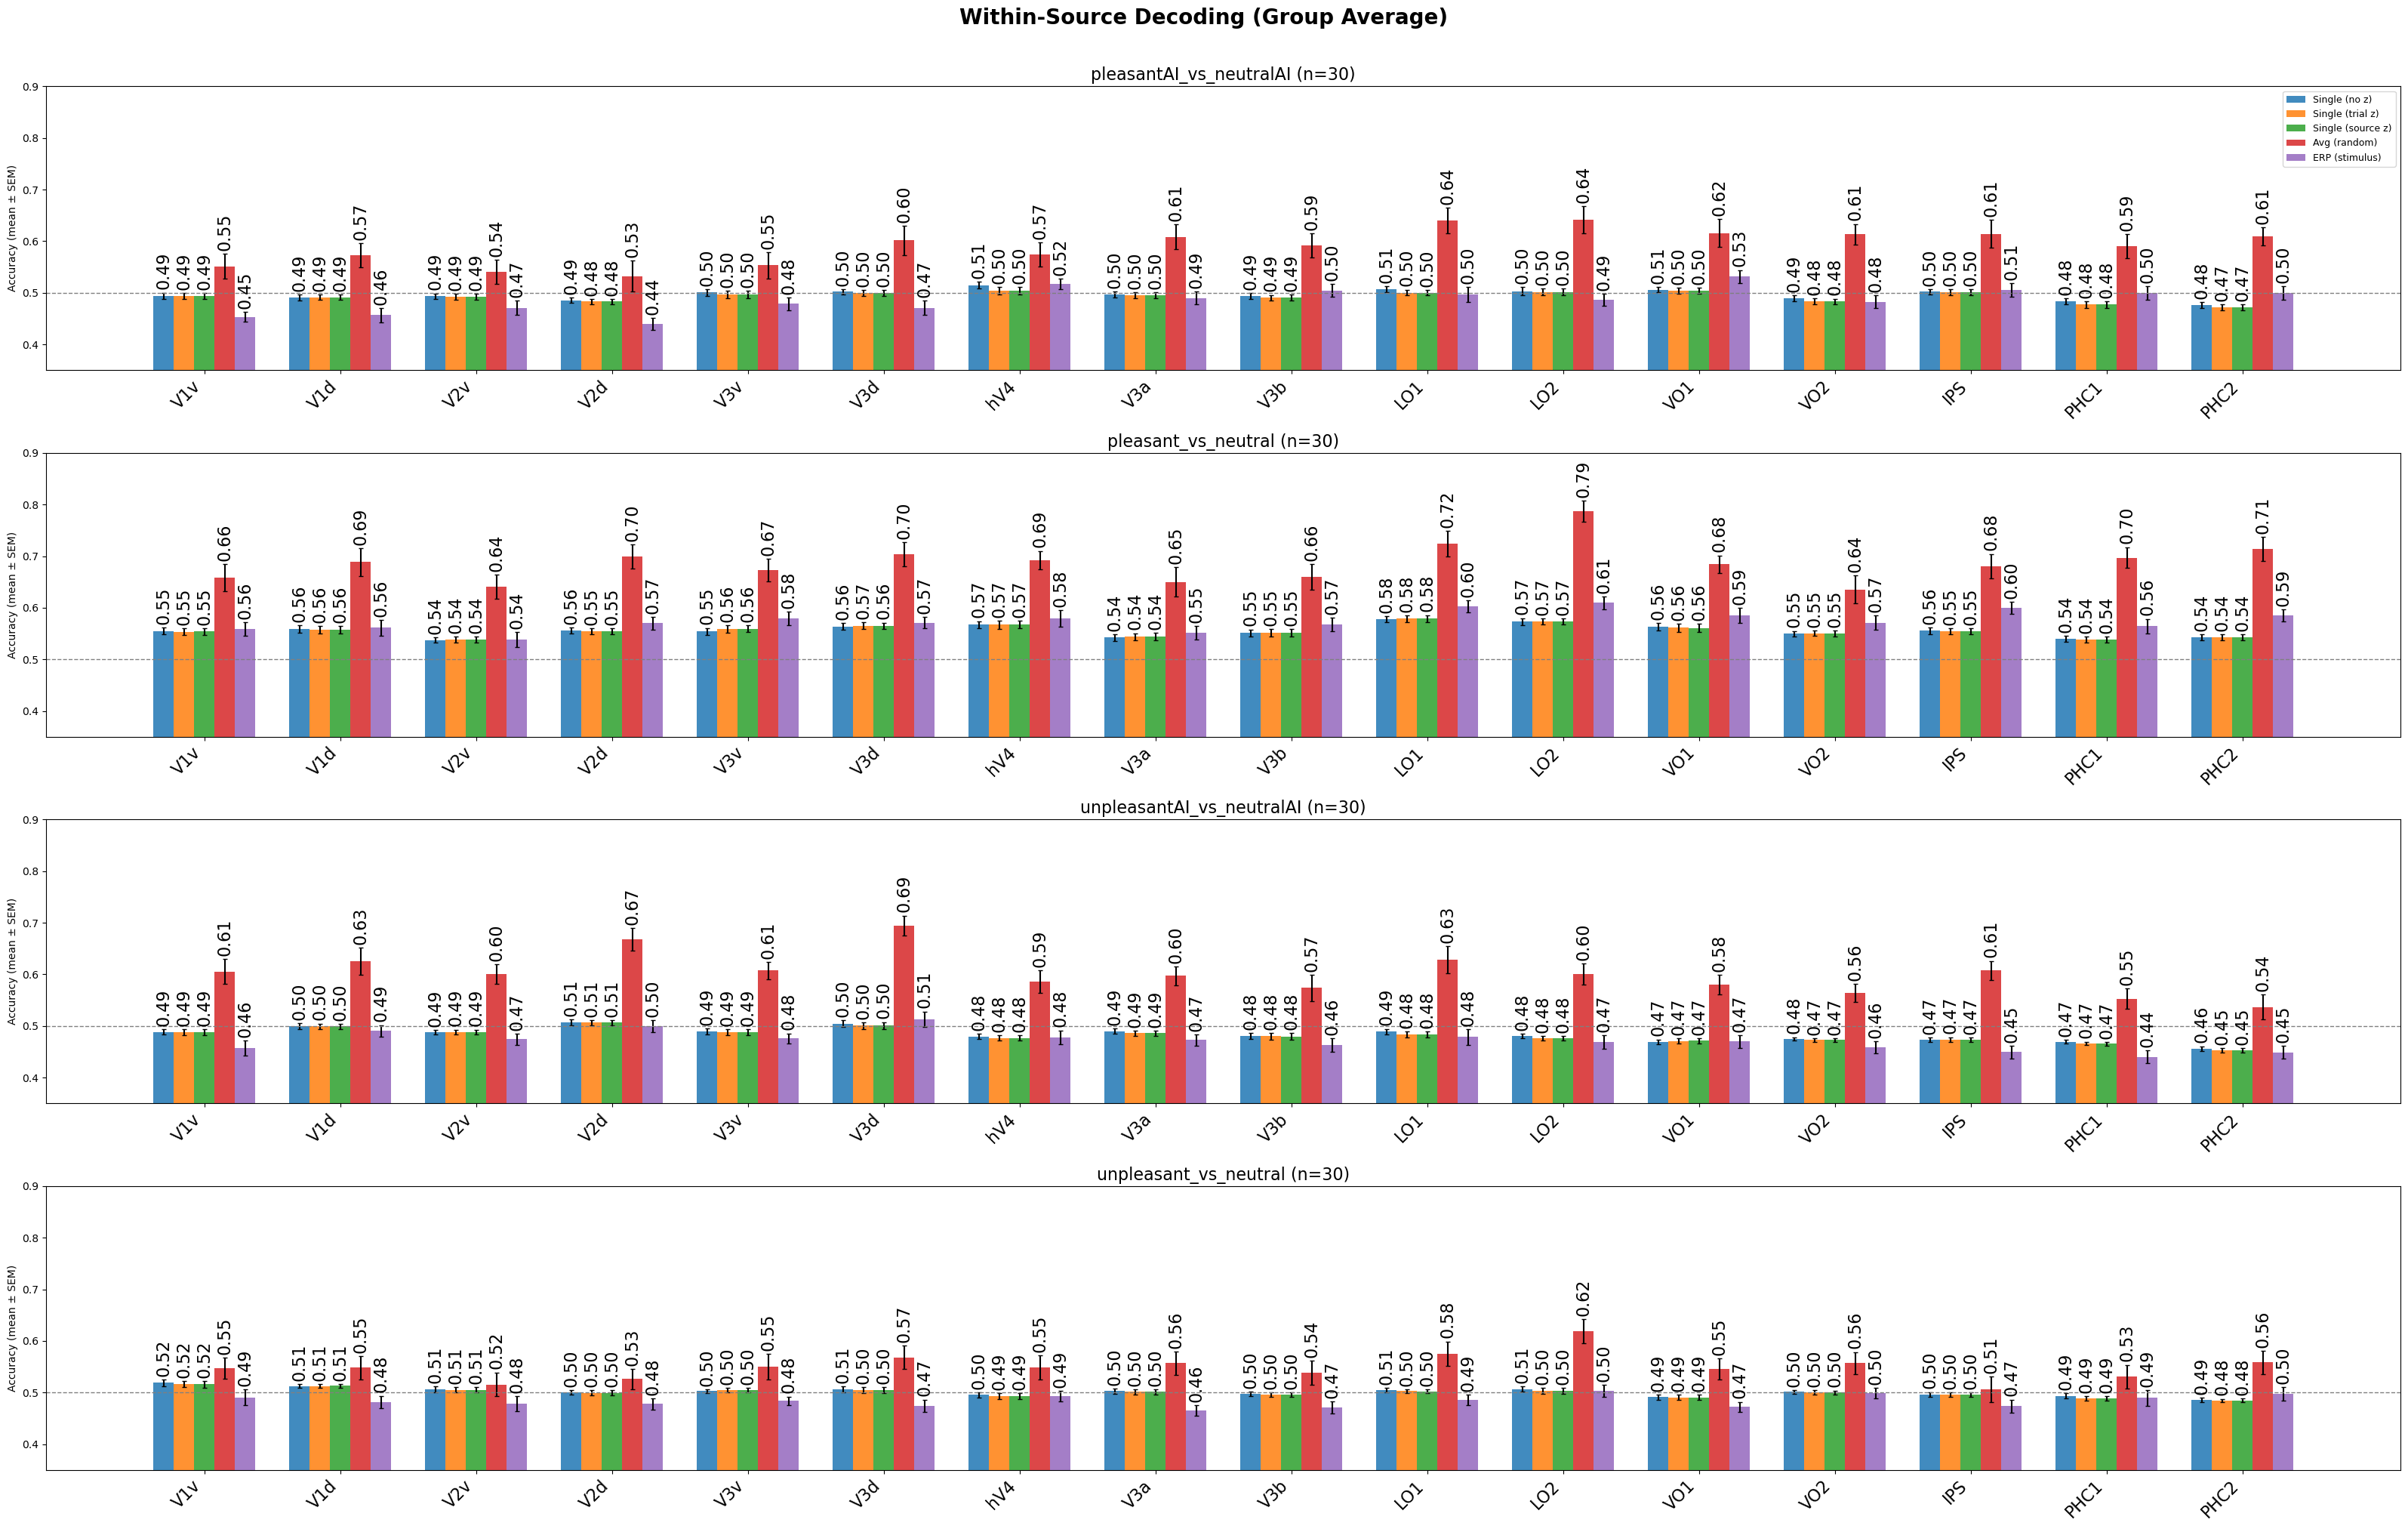

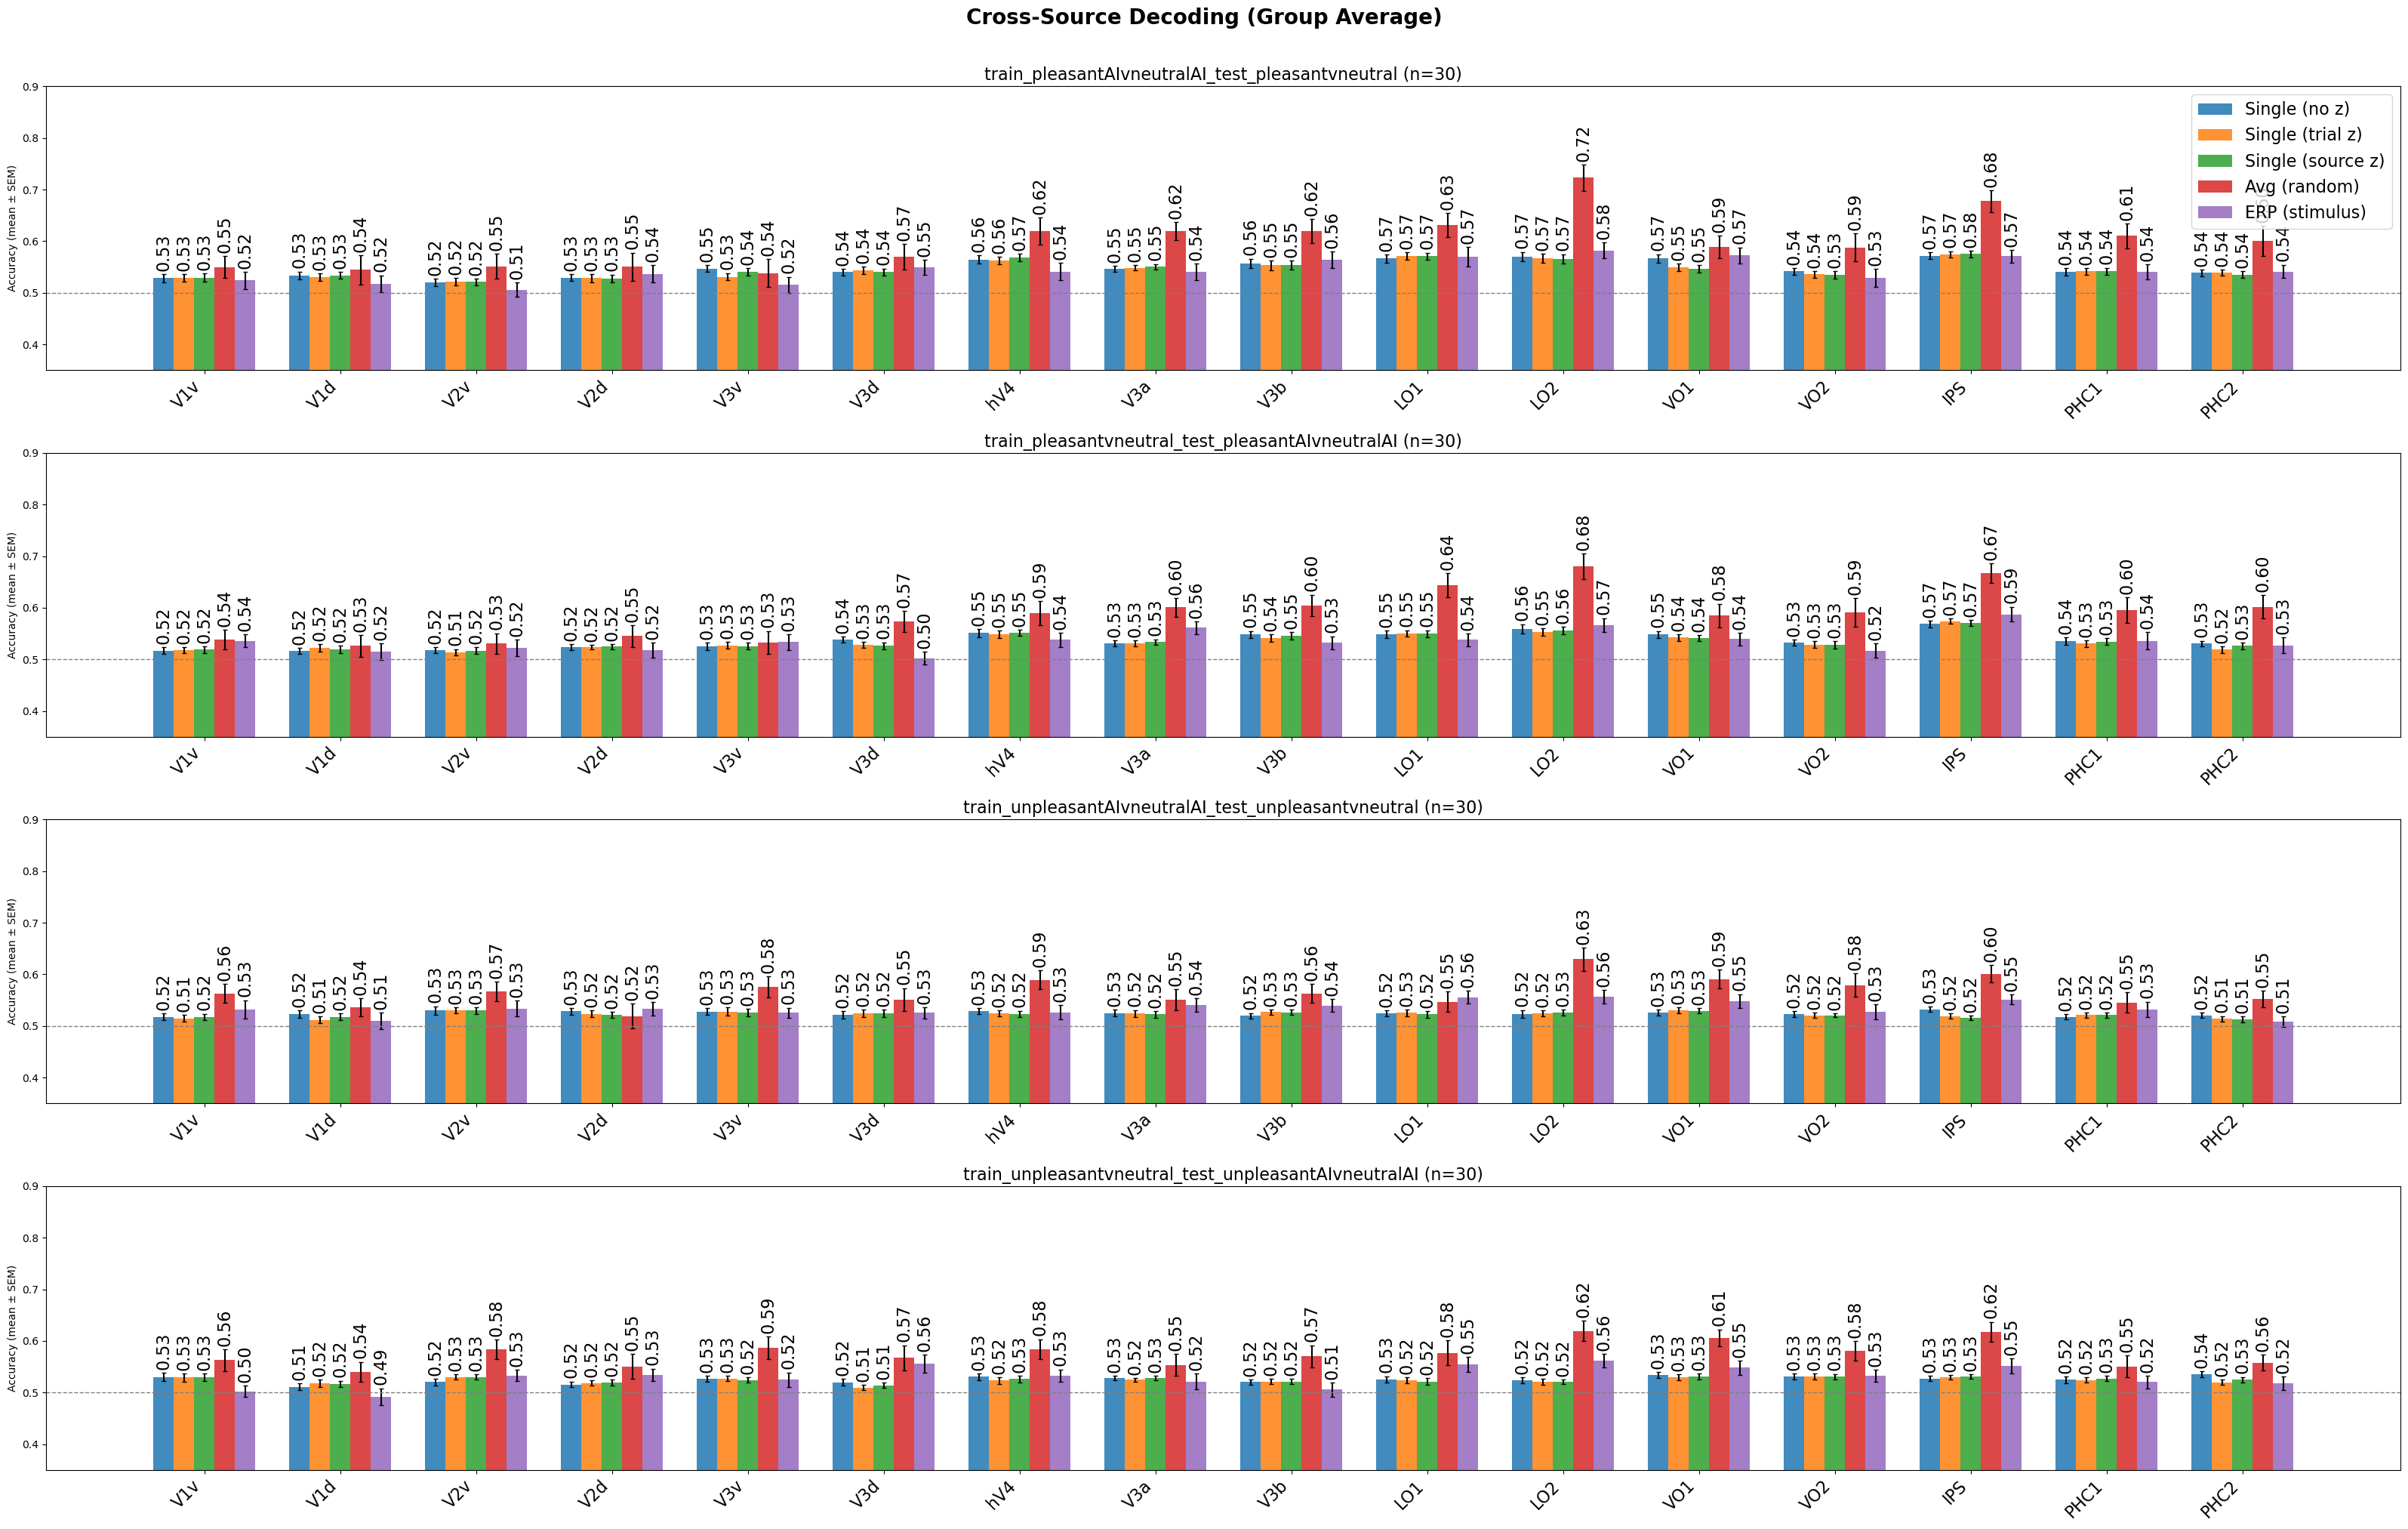

In [16]:
roi_names = list(roi_masks.keys())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
method_labels = ['Single (no z)', 'Single (trial z)', 'Single (source z)', 'Avg (random)', 'ERP (stimulus)']

def collect_method_data(comp, result_single, result_avg, result_erp):
    """Collect (n_subs x n_rois) arrays for each of the 5 methods."""
    methods = []
    for zk in ['no_zscore', 'trial_zscore', 'source_zscore']:
        arr = np.array([[result_single[s][comp][zk].get(r, np.nan) for r in roi_names] for s in subs])
        methods.append(arr)
    for res in [result_avg, result_erp]:
        arr = np.array([[res[s][comp].get(r, np.nan) for r in roi_names] for s in subs])
        methods.append(arr)
    return methods

# --- Within-Source Plot ---
fig, axes = plt.subplots(len(within_comparisons), 1,
                          figsize=(max(18, len(roi_names)*2), 5*len(within_comparisons)),
                          squeeze=False)

for row, (cond1, cond2) in enumerate(within_comparisons):
    comp = f"{cond1}_vs_{cond2}"
    ax = axes[row, 0]
    method_data = collect_method_data(comp, results_within_single, results_within_avg, results_within_erp)

    x = np.arange(len(roi_names))
    n_m = len(method_data)
    width = 0.15

    for mi, (md, color, lab) in enumerate(zip(method_data, colors, method_labels)):
        means = np.nanmean(md, axis=0)
        sems = np.nanstd(md, axis=0) / np.sqrt(np.sum(~np.isnan(md), axis=0))
        offset = (mi - (n_m-1)/2) * width
        bars = ax.bar(x + offset, means, width, yerr=sems, color=color,
                      label=lab, capsize=2, alpha=0.85)
        ax.bar_label(bars, fmt='%.2f', fontsize=16, rotation=90, padding=3)

    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_ylabel('Accuracy (mean \u00b1 SEM)')
    ax.set_title(f'{comp} (n={len(subs)})', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(roi_names, rotation=45, ha='right', fontsize=16)
    ax.set_ylim([0.35, 0.9])
    if row == 0:
        ax.legend(fontsize=9, loc='upper right')

fig.suptitle('Within-Source Decoding (Group Average)', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- Cross-Source Plot ---
fig, axes = plt.subplots(len(cross_comparisons), 1,
                          figsize=(max(18, len(roi_names)*2), 5*len(cross_comparisons)),
                          squeeze=False)

for row, (tc1, tc2, te1, te2) in enumerate(cross_comparisons):
    comp = f"train_{tc1}v{tc2}_test_{te1}v{te2}"
    ax = axes[row, 0]
    method_data = collect_method_data(comp, results_cross_single, results_cross_avg, results_cross_erp)

    x = np.arange(len(roi_names))
    n_m = len(method_data)
    width = 0.15

    for mi, (md, color, lab) in enumerate(zip(method_data, colors, method_labels)):
        means = np.nanmean(md, axis=0)
        sems = np.nanstd(md, axis=0) / np.sqrt(np.sum(~np.isnan(md), axis=0))
        offset = (mi - (n_m-1)/2) * width
        bars = ax.bar(x + offset, means, width, yerr=sems, color=color,
                      label=lab, capsize=2, alpha=0.85)
        ax.bar_label(bars, fmt='%.2f', fontsize=16, rotation=90, padding=3)

    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_ylabel('Accuracy (mean \u00b1 SEM)')
    ax.set_title(f'{comp} (n={len(subs)})', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(roi_names, rotation=45, ha='right', fontsize=16)
    ax.set_ylim([0.35, 0.9])
    if row == 0:
        ax.legend(fontsize=16, loc='upper right')

fig.suptitle('Cross-Source Decoding (Group Average)', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

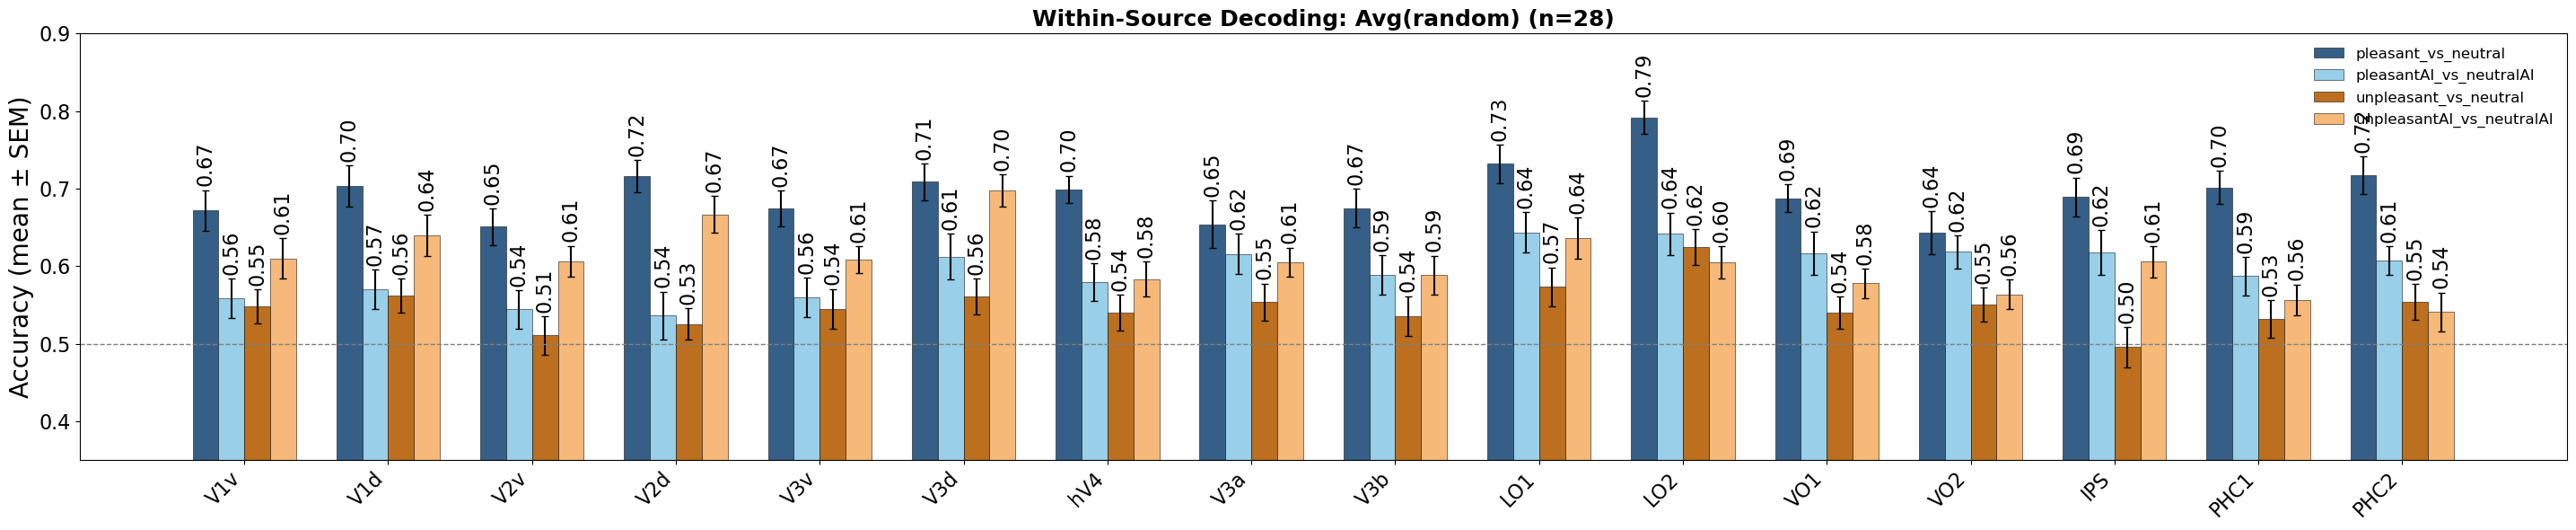

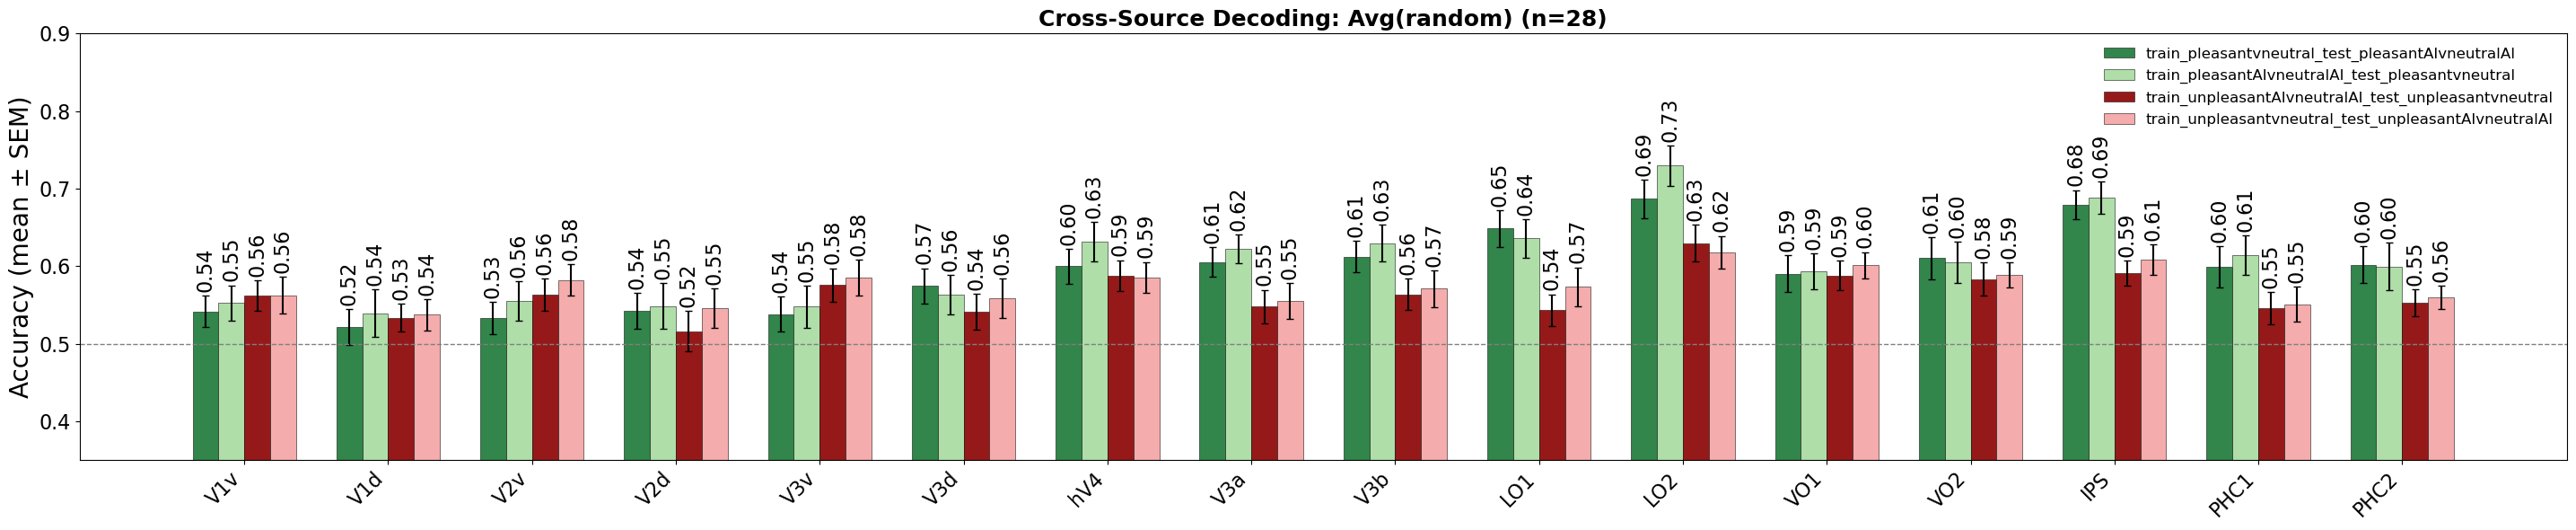

In [28]:
# ============================
# Subjects: remove Sub3, Sub8
# ============================
subs_plot = [s for s in subs if s not in ['Sub3', 'Sub8']]

roi_names = list(roi_masks.keys())

# Professional journal-style RGB/hex colors
within_colors = {
    'pleasant_vs_neutral': '#1f4e79',        # dark blue
    'pleasantAI_vs_neutralAI': '#8ecae6',    # light blue
    'unpleasant_vs_neutral': '#b45f06',      # dark orange
    'unpleasantAI_vs_neutralAI': '#f6b26b'   # light orange
}

cross_colors = {
    'train_pleasantvneutral_test_pleasantAIvneutralAI': '#1b7837',      # dark green
    'train_pleasantAIvneutralAI_test_pleasantvneutral': '#a6dba0',      # light green
    'train_unpleasantAIvneutralAI_test_unpleasantvneutral': '#8b0000',  # dark red
    'train_unpleasantvneutral_test_unpleasantAIvneutralAI': '#f4a3a3'   # light red / pink-red
}

def collect_avg_random_data(comp, result_avg):
    """Collect Avg(random) only: n_subs x n_rois."""
    arr = np.array([
        [result_avg[s][comp].get(r, np.nan) for r in roi_names]
        for s in subs_plot
    ])
    return arr


# ============================
# Within-Source: Avg(random) only
# ============================
within_plot_comps = [
    'pleasant_vs_neutral',
    'pleasantAI_vs_neutralAI',
    'unpleasant_vs_neutral',
    'unpleasantAI_vs_neutralAI'
]

fig, ax = plt.subplots(
    1, 1,
    figsize=(max(18, len(roi_names) * 1.8), 6)
)

x = np.arange(len(roi_names))
width = 0.18
n_c = len(within_plot_comps)

for ci, comp in enumerate(within_plot_comps):
    md = collect_avg_random_data(comp, results_within_avg)

    means = np.nanmean(md, axis=0)
    sems = np.nanstd(md, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(md), axis=0))

    offset = (ci - (n_c - 1) / 2) * width

    bars = ax.bar(
        x + offset,
        means,
        width,
        yerr=sems,
        color=within_colors[comp],
        label=comp,
        capsize=3,
        alpha=0.9,
        edgecolor='black',
        linewidth=0.4
    )

    ax.bar_label(
        bars,
        fmt='%.2f',
        fontsize=16,
        rotation=90,
        padding=3
    )

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)

ax.set_ylabel('Accuracy (mean ± SEM)', fontsize=20)
ax.set_title(f'Within-Source Decoding: Avg(random) (n={len(subs_plot)})',
             fontsize=18, fontweight='bold')
ax.tick_params(axis='y', labelsize=16)
ax.set_xticks(x)
ax.set_xticklabels(roi_names, rotation=45, ha='right', fontsize=16)
ax.set_ylim([0.35, 0.9])

ax.legend(fontsize=12, frameon=False, loc='upper right')

plt.tight_layout()
plt.show()


# ============================
# Cross-Source: Avg(random) only
# ============================
cross_plot_comps = [
    'train_pleasantvneutral_test_pleasantAIvneutralAI',
    'train_pleasantAIvneutralAI_test_pleasantvneutral',
    'train_unpleasantAIvneutralAI_test_unpleasantvneutral',
    'train_unpleasantvneutral_test_unpleasantAIvneutralAI'
]

fig, ax = plt.subplots(
    1, 1,
    figsize=(max(18, len(roi_names) * 1.8), 6)
)

x = np.arange(len(roi_names))
width = 0.18
n_c = len(cross_plot_comps)

for ci, comp in enumerate(cross_plot_comps):
    md = collect_avg_random_data(comp, results_cross_avg)

    means = np.nanmean(md, axis=0)
    sems = np.nanstd(md, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(md), axis=0))

    offset = (ci - (n_c - 1) / 2) * width

    bars = ax.bar(
        x + offset,
        means,
        width,
        yerr=sems,
        color=cross_colors[comp],
        label=comp,
        capsize=3,
        alpha=0.9,
        edgecolor='black',
        linewidth=0.4
    )

    ax.bar_label(
        bars,
        fmt='%.2f',
        fontsize=16,
        rotation=90,
        padding=3
    )

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)

ax.set_ylabel('Accuracy (mean ± SEM)', fontsize=20)
ax.set_title(f'Cross-Source Decoding: Avg(random) (n={len(subs_plot)})',
             fontsize=18, fontweight='bold')
ax.tick_params(axis='y', labelsize=16)
ax.set_xticks(x)
ax.set_xticklabels(roi_names, rotation=45, ha='right', fontsize=16)
ax.set_ylim([0.35, 0.9])

ax.legend(fontsize=12, frameon=False, loc='upper right')

plt.tight_layout()
plt.show()

## Save Results

In [15]:
output_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results'
os.makedirs(output_dir, exist_ok=True)

all_results = {
    'within_single': results_within_single,
    'within_avg': results_within_avg,
    'within_erp': results_within_erp,
    'cross_single': results_cross_single,
    'cross_avg': results_cross_avg,
    'cross_erp': results_cross_erp,
    'subs': subs,
    'roi_names': roi_names,
    'within_comparisons': within_comparisons,
    'cross_comparisons': cross_comparisons,
}

save_path = os.path.join(output_dir, 'decoding_multisub.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(all_results, f)
print(f"Results saved to: {save_path}")

Results saved to: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\decoding_multisub.pkl
